# Classification

## Import

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
# 画图工具在tools文件夹中，tools下的 __init__.py文件表示这是一个Python包。 
# 参考链接：https://blog.csdn.net/wokaowokaowokao12345/article/details/128934877
from tools.plot import show_minist, plot_loss 

## Load the MNIST dataset

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [02:44<00:00, 60.4kB/s]


Extracting /data\MNIST\raw\train-images-idx3-ubyte.gz to /data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 101kB/s]


Extracting /data\MNIST\raw\train-labels-idx1-ubyte.gz to /data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:02<00:00, 601kB/s]


Extracting /data\MNIST\raw\t10k-images-idx3-ubyte.gz to /data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


Extracting /data\MNIST\raw\t10k-labels-idx1-ubyte.gz to /data\MNIST\raw



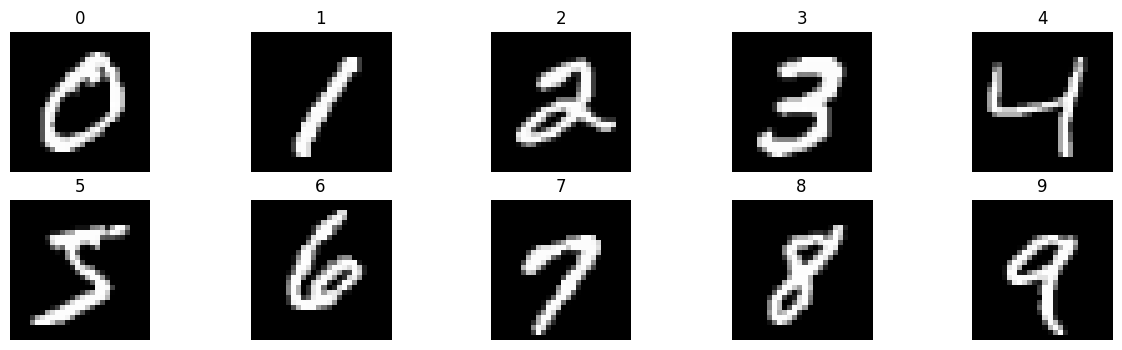

In [2]:
# 定义了一个单通道图像预处理的转换管道，先将图像转换为张量，然后对图像进行均值和标准差均为0.5的归一化处理
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# TODO:
# 1. 使用 PyTorch 的 torchvision.datasets.MNIST 加载数据集。
# 2. 使用 DataLoader 创建训练数据加载器
train_dataset = datasets.MNIST(root='/data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64)
 
show_minist(train_loader)

## Implement the MLP model

In [5]:
# 模型定义
class MLP(nn.Module):
    def __init__(self, input_dim = 28*28, hidden_dim = 128, num_classes = 10):
        """
        Initialize a MLP model
        Args:
            input dim: int, the dimension of input data(28*28 for MNIST)
            hidden dim: int, the dimension of hidden layer
            num_classes: int, the number of classes (10 for MNIST)
        """
        super(MLP, self).__init__()
        # TODO: Define the layers of MLP 
        # 1. Flatten the input data
        # 2. A fully connected layer with input_dim and hidden_dim
        # 3. A fully connected layer with hidden_dim and num_classes
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        

    
    def forward(self, x):
        """
        Forward pass of the MLP model
        Args:
            x: torch.Tensor, Input tensor of shape (batch_size, 1, 28, 28)
        Returns:
            x: torch.Tensor, Output tensor of shape (batch_size, num_classes)
        """
        # TODO: Implement the forward pass
        # 1. Flatten the input data
        # 2. Fully connected layer1 and ReLU activation function
        # 3. Fully connected layer2 and Return the output
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)

        return x

In [6]:
# 实现训练一个batch的过程
def train_one_batch(model, data, labels, optimizer, criterion, device):
    """
    Args:
        model (nn.Module): 网络模型
        inputs (torch.Tensor): 输入数据，维度为 (batch_size, channels, height, width)
        labels (torch.Tensor): 标签，维度为 (batch_size,)
        optimizer (torch.optim.Optimizer): 优化器（如 torch.optim.SGD）
        criterion (nn.Module): 损失函数（如 nn.CrossEntropyLoss）
        device (torch.device): 运行设备（'cpu' 或 'cuda'）
    
    Returns:
        tuple: (loss, outputs)
            - loss (torch.Tensor): 当前批次的损失值（标量）
            - outputs (torch.Tensor): 模型输出，维度为 (batch_size, num_classes)
    """
    # TODO: 实现训练一个batch的过程
    # 1. 将输入和标签移动到指定的设备
    # 2. 前向传播：计算模型输出
    # 3. 计算损失
    # 4. 反向传播：计算梯度
    # 5. 更新参数
    # 6. 将优化器的梯度清零
    data,labels =data.to(device),labels.to(device)
    outputs =model(data)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    
    return loss, outputs

## Train the model

In [ ]:
# 实现训练过程
def train(optimizer, model, train_loader, criterion, epochs=10, device='cuda'):
    losses = []
    model.train()
    
    # 训练epochs次
    for epoch in range(epochs):
        epoch_losses = 0 
        epoch_correct = 0
        epoch_total = 0
        
        for data, labels in train_loader:
            loss, outputs = train_one_batch(model, data, labels, optimizer, criterion, device) # 训练一个batch的数据
            epoch_losses += loss.item()
            losses.append(loss.item())
            
            # 对输出结果在第1个维度（类别维度）取最大值，得到每个样本的预测类别，并将张量从GPU移动到CPU内存中
            pred = outputs.argmax(dim=1, keepdim=True).cpu()
            # 将labes形状调整为和pred同样的形状(batch_size, 1)比较，统计预测正确的数量
            correct = pred.eq(labels.view_as(pred)).sum().item() 

            # 另一种写法
            # pred = outputs.argmax(dim=1).cpu()
            # correct = pred.eq(labels).sum().item()
            
            epoch_correct += correct
            epoch_total += data.size(0)
        
        avg_train_loss = epoch_losses / len(train_loader)
        accuracy = epoch_correct / epoch_total
        
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_train_loss:.4f}, Accuracy: {accuracy:.4f}')
    
    return losses

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

# TODO: 分别使用 SGD, Momentum 和 Adam三种优化器, 训练模型。 调用plot_loss函数绘制三种优化器的loss曲线。    
# 1. 构建模型
# 2. 选择优化器
# 3. 调用train函数训练模型
# 4. 调用plot_loss函数绘制loss曲线
# NOTE: 请按照如下参数设置进行训练：
        # (1) SGD: 初始学习率0.01, 
        # (2) Momentum: 初始学习率为0.01, 动量系数为0.9, 
        # (3) Adam: 初始学习率0.01

# train with SGD
model_sgd = MLP().to(device)
optimizer_sgd = optim.SGD(model_sgd.parameters(),lr=0.01)
losses_sgd = train(optimizer_sgd, model_sgd, train_loader, criterion, epochs=6, device=device)
plot_loss(losses_sgd, title='SGD') # 绘制loss曲线

# train with Momentum
model_momentum = MLP().to(device)
optimizer_momentum = optim.SGD(model_momentum.parameters(),lr=0.01,momentum=0.9)
losses_sgd = train(optimizer_momentum, model_momentum, train_loader, criterion, epochs=6, device=device)
plot_loss(losses_sgd, title='Momentum') # 绘制loss曲线

# train with Adam
model_adam = MLP().to(device)
optimizer_adam = optim.Adam(model_adam.parameters(),lr=0.01)
losses_sgd = train(optimizer_adam, model_adam, train_loader, criterion, epochs=6, device=device)
plot_loss(losses_sgd, title='Adam') # 绘制loss曲线